# Proyecto Final - Análisis de Datos 
# Formula 1
### 03 - Analisis Exploratorio
**Integrantes:** 
- Esquivel, Kevin
- Simmons, Abigail
- Solis, Luis
- Villarreal, Sergio

**Fecha:** Julio 2026  

En este notebook realizamos la **estadística descriptiva** del proyecto: promedios y medidas de
resumen, distribuciones de las variables numéricas y categóricas más relevantes, y un análisis
de **top escuderías** bajo distintos criterios (puntos, presupuesto, patrocinio y campeonatos de
sus pilotos).

Partimos de las tablas ya registradas y limpiadas en los notebooks "01_ingesta_datos" y
"02_limpieza_datos", por lo que aquí solo leemos y no volvemos a limpiar nada.

## Preparación para tratar los datos
Librerías y carga de tablas.

In [0]:
# Librerias para el analisis y las graficas
# Convertimos de Spark a pandas porque el volumen de datos es pequeno
# y pandas, matplotlib y seaborn son mas comodos para estadistica descriptiva

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# Formato de despliegue: dinero a 2 decimales, el resto a 3
pd.options.display.float_format = lambda x: f"{x:,.3f}"

def fmt_dinero(x, pos=None):
    return f"${x:,.2f}"

# Cargamos las tablas que ya quedaron limpias en el notebook 02
temporada     = spark.table("temporada").toPandas()
circuito      = spark.table("circuito").toPandas()
escuderia     = spark.table("escuderia").toPandas()
patrocinador  = spark.table("patrocinador").toPandas()
piloto        = spark.table("piloto").toPandas()
ingeniero     = spark.table("ingeniero").toPandas()
carrera       = spark.table("carrera").toPandas()
auto          = spark.table("auto").toPandas()
vuelta        = spark.table("vuelta").toPandas()
resultado     = spark.table("resultado").toPandas()
tiempo_vuelta = spark.table("tiempo_vuelta").toPandas()
financiamiento= spark.table("financiamiento").toPandas()


print("Tablas cargadas en pandas:")
for nombre, df in [("temporada", temporada), ("circuito", circuito), ("escuderia", escuderia),
                    ("patrocinador", patrocinador), ("piloto", piloto), ("ingeniero", ingeniero),
                    ("carrera", carrera), ("auto", auto), ("vuelta", vuelta),
                    ("resultado", resultado), ("tiempo_vuelta", tiempo_vuelta),
                    ("financiamiento", financiamiento)]:
    print(f"  {nombre}: {df.shape[0]} filas, {df.shape[1]} columnas")

Tablas cargadas en pandas:
  temporada: 76 filas, 3 columnas
  circuito: 70 filas, 5 columnas
  escuderia: 21 filas, 5 columnas
  patrocinador: 50 filas, 3 columnas
  piloto: 50 filas, 8 columnas
  ingeniero: 30 filas, 6 columnas
  carrera: 120 filas, 8 columnas
  auto: 50 filas, 8 columnas
  vuelta: 7536 filas, 2 columnas
  resultado: 2400 filas, 5 columnas
  tiempo_vuelta: 75360 filas, 5 columnas
  financiamiento: 135 filas, 3 columnas


## 1. Estadísticas descriptivas generales
Calculamos las datos básicos, por ejemplo media, mediana, desviación estándar, mínimos, máximos, ect. para las variables numéricas más relevantes de cada tabla.

In [0]:
# 1.1 Escuderias: presupuesto (USD, 2 decimales por ser dinero)
print("=== Escuderias: presupuesto (USD) ===")
display(escuderia["presupuesto"].describe().round(2).to_frame(name="presupuesto (USD)"))

# 1.2 Pilotos: peso (kg, 3 decimales) y campeonatos (columna original es entera;
# los estadisticos como media/std son necesariamente decimales aunque el dato
# de origen sea entero -- por eso se ve "0,1,2..." en la tabla cruda y decimales aqui)
print("\n=== Pilotos: peso (kg) y campeonatos ===")
display(piloto[["peso", "cantidad_campeonatos"]].describe().round(3))

# 1.3 Carreras: temperatura (°C), probabilidad de lluvia (%) y vueltas (conteo)
print("\n=== Carreras: temperatura (°C), lluvia (%) y vueltas (conteo) ===")
display(carrera[["temperatura", "probabilidad_lluvia", "cantidad_vueltas"]].describe().round(3))

# 1.4 Resultados: posicion final y puntos -> enteros estrictos, sin decimales
print("\n=== Resultados: posicion final y puntos (valores enteros) ===")
resumen_resultado = resultado[["posicion_final", "puntos_obtenidos"]].describe()
resumen_resultado.loc[["min", "25%", "50%", "75%", "max"]] = resumen_resultado.loc[["min", "25%", "50%", "75%", "max"]].astype(int)
display(resumen_resultado.round(3))

# 1.5 Financiamiento: monto de aporte (USD, 2 decimales)
print("\n=== Financiamiento: monto de aporte (USD) ===")
display(financiamiento["monto_aporte"].describe().round(2).to_frame(name="monto_aporte (USD)"))

# 1.6 Posicion y puntos promedio DESGLOSADOS POR ESCUDERIA
resultado_por_escuderia = (
    resultado.merge(auto[["id_piloto", "id_escuderia"]], on="id_piloto", how="left")
    .merge(escuderia[["id_escuderia", "nombre"]], on="id_escuderia", how="left")
    .groupby("nombre")
    .agg(
        posicion_promedio=("posicion_final", "mean"),
        puntos_promedio=("puntos_obtenidos", "mean"),
        puntos_totales=("puntos_obtenidos", "sum"),
        cantidad_resultados=("puntos_obtenidos", "count"),
    )
    .round(3)
    .sort_values("puntos_totales", ascending=False)
)

print("=== Posicion y puntos promedio por escuderia ===")
display(resultado_por_escuderia)

# 1.7 Promedios generales
promedios = {
    "Presupuesto promedio por escuderia (USD)": round(escuderia["presupuesto"].mean(), 2),
    "Peso promedio de los pilotos (kg)":        round(piloto["peso"].mean(), 3),
    "Campeonatos promedio por piloto":          round(piloto["cantidad_campeonatos"].mean(), 3),
    "Temperatura promedio en carrera (°C)":     round(carrera["temperatura"].mean(), 3),
    "Probabilidad de lluvia promedio (%)":      round(carrera["probabilidad_lluvia"].mean(), 3),
    "Vueltas promedio por carrera":             round(carrera["cantidad_vueltas"].mean(), 3),
    "Puntos promedio por resultado":            round(resultado["puntos_obtenidos"].mean(), 3),
    "Aporte promedio de patrocinio (USD)":      round(financiamiento["monto_aporte"].mean(), 2),
}

print("PROMEDIOS GENERALES DEL PROYECTO\n")
for etiqueta, valor in promedios.items():
    print(f"- {etiqueta}: {valor:,}")

=== Escuderias: presupuesto (USD) ===


presupuesto (USD)
21.0
3.7062779579E8
1.3796360351E8
1.5097514721E8
3.0205024105E8
3.5479287586E8
4.572830873E8
5.8880770949E8



=== Pilotos: peso (kg) y campeonatos ===


peso,cantidad_campeonatos
50.0,50.0
70.637,1.0
3.047,1.761
65.5,0.0
68.3,0.0
69.925,0.0
72.362,1.75
79.3,7.0



=== Carreras: temperatura (°C), lluvia (%) y vueltas (conteo) ===


...


=== Financiamiento: monto de aporte (USD) ===


monto_aporte (USD)
135.0
3.632332229E7
1.228284513E7
1.23456789E7
2.56789013E7
3.45678908E7
4.567890175E7
6.789012345E7


=== Posicion y puntos promedio por escuderia ===


posicion_promedio,puntos_promedio,puntos_totales,cantidad_resultados
10.533,4.997,1884,377
9.904,5.221,1749,335
9.894,5.677,1124,198
10.814,4.457,838,188
10.978,4.489,826,184
11.72,3.614,748,207
10.102,5.898,578,98
10.51,5.68,568,100
11.119,4.424,522,118
9.965,5.718,486,85


PROMEDIOS GENERALES DEL PROYECTO

- Presupuesto promedio por escuderia (USD): 370,627,795.79
- Peso promedio de los pilotos (kg): 70.637
- Campeonatos promedio por piloto: 1.0
- Temperatura promedio en carrera (°C): 25.171
- Probabilidad de lluvia promedio (%): 34.294
- Vueltas promedio por carrera: 62.8
- Puntos promedio por resultado: 5.05
- Aporte promedio de patrocinio (USD): 36,323,322.29


## 2. Distribuciones
Visualizamos cómo se distribuyen las variables numéricas y categóricas.

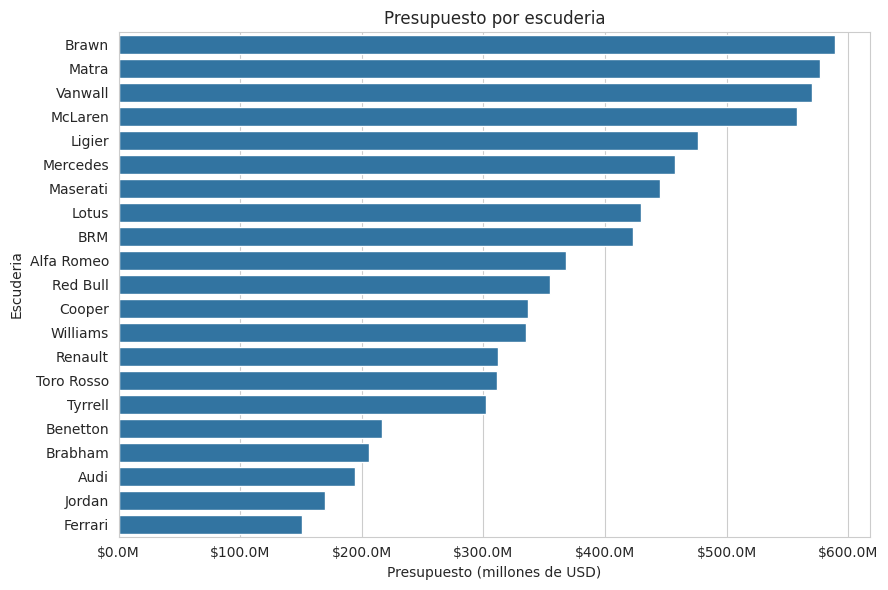

In [0]:
# 2.1 Presupuesto por escuderia
pres_ordenado = escuderia[["nombre", "presupuesto"]].sort_values("presupuesto", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=pres_ordenado, x="presupuesto", y="nombre", ax=ax, color="#1f77b4")
ax.set_title("Presupuesto por escuderia")
ax.set_xlabel("Presupuesto (millones de USD)")
ax.set_ylabel("Escuderia")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"${x/1e6:,.1f}M"))
plt.tight_layout()
plt.show()

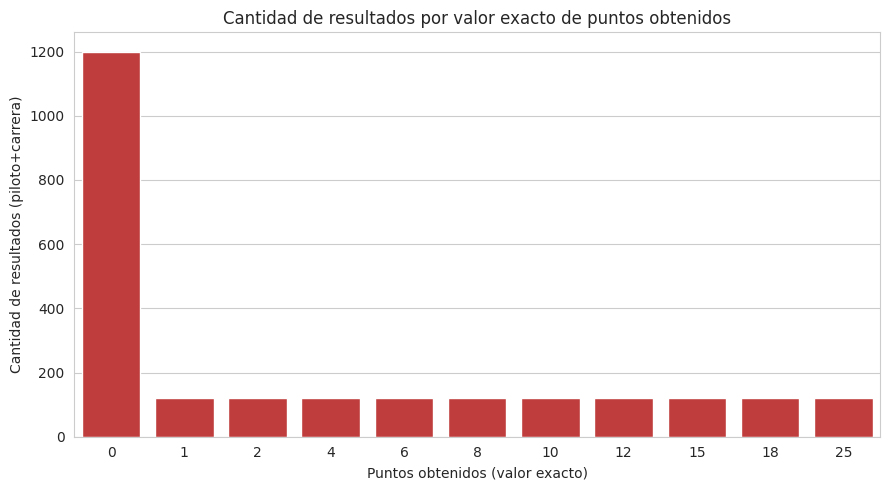

Nota: cada 'resultado' = un piloto en una carrera especifica. La barra en 0
muestra cuantos resultados no sumaron puntos (fuera de zona de puntos).


In [0]:
# 2.2 Puntos obtenidos
puntos_conteo = resultado["puntos_obtenidos"].value_counts().sort_index()

fig, ax = plt.subplots()
sns.barplot(x=puntos_conteo.index.astype(int), y=puntos_conteo.values, ax=ax, color="#d62728")
ax.set_title("Cantidad de resultados por valor exacto de puntos obtenidos")
ax.set_xlabel("Puntos obtenidos (valor exacto)")
ax.set_ylabel("Cantidad de resultados (piloto+carrera)")
plt.tight_layout()
plt.show()
print("Nota: cada 'resultado' = un piloto en una carrera especifica. La barra en 0")
print("muestra cuantos resultados no sumaron puntos (fuera de zona de puntos).")

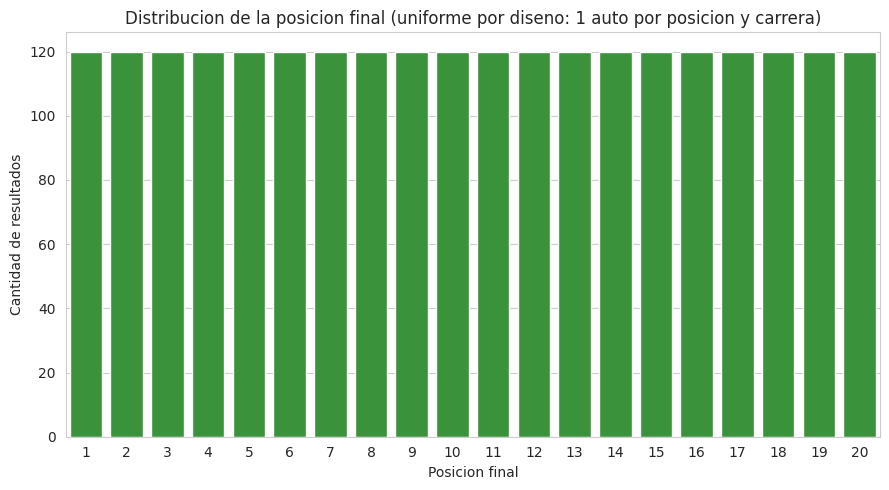

In [0]:
# 2.3 Distribucion de la posicion final de llegada
fig, ax = plt.subplots()
sns.countplot(x=resultado["posicion_final"].astype(int), ax=ax, color="#2ca02c")
ax.set_title("Distribucion de la posicion final (uniforme por diseno: 1 auto por posicion y carrera)")
ax.set_xlabel("Posicion final")
ax.set_ylabel("Cantidad de resultados")
plt.tight_layout()
plt.show()

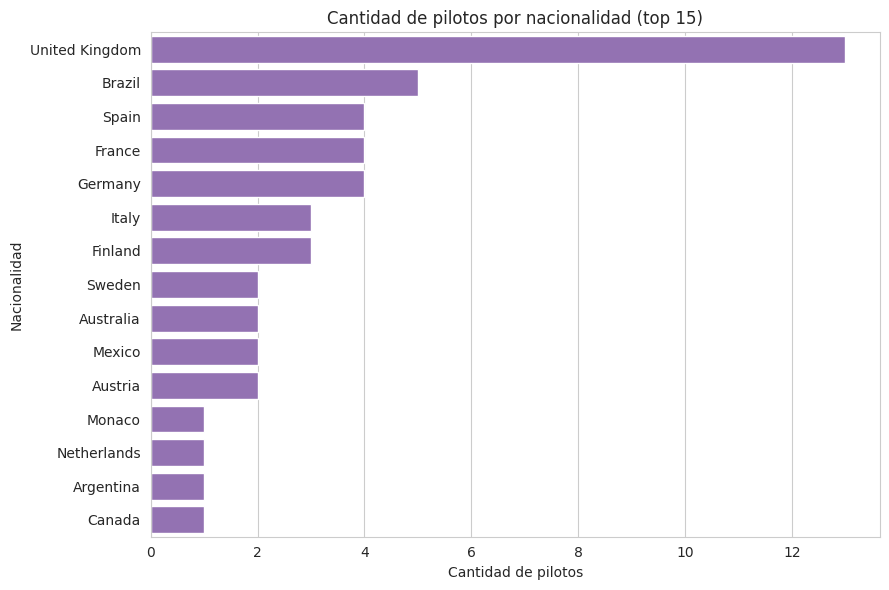

In [0]:
# 2.4 Distribucion de pilotos por nacionalidad (top 15)
top_nacionalidades = piloto["nacionalidad"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_nacionalidades.values, y=top_nacionalidades.index, ax=ax, color="#9467bd")
ax.set_title("Cantidad de pilotos por nacionalidad (top 15)")
ax.set_xlabel("Cantidad de pilotos")
ax.set_ylabel("Nacionalidad")
plt.tight_layout()
plt.show()

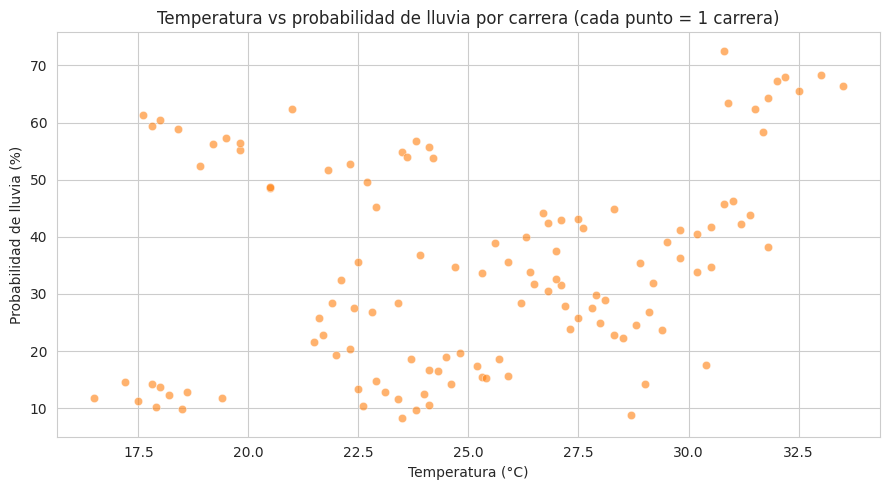

Correlacion temperatura-lluvia: 0.272 (relacion notable)


In [0]:
# 2.5 Temperatura vs probabilidad de lluvia
fig, ax = plt.subplots()
sns.scatterplot(data=carrera, x="temperatura", y="probabilidad_lluvia", ax=ax, alpha=0.6, color="#ff7f0e")
ax.set_title("Temperatura vs probabilidad de lluvia por carrera (cada punto = 1 carrera)")
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Probabilidad de lluvia (%)")
plt.tight_layout()
plt.show()
corr_temp_lluvia = carrera["temperatura"].corr(carrera["probabilidad_lluvia"])
print(f"Correlacion temperatura-lluvia: {corr_temp_lluvia:.3f} "
      f"({'sin relacion aparente' if abs(corr_temp_lluvia) < 0.2 else 'relacion notable'})")

## 3. Top Escuderías
Analizamos el desempeño de las escuderías desde múltiples ángulos:
- Puntos totales acumulados
- Presupuesto
- Patrocinio recibido
- Peso de campeonatos que traen los pilotos

=== Top 10 escuderias por puntos totales ===


nombre,puntos_obtenidos
Ferrari,1884
McLaren,1749
Williams,1124
Renault,838
Alfa Romeo,826
Lotus,748
Ligier,578
Red Bull,568
Tyrrell,522
Toro Rosso,486


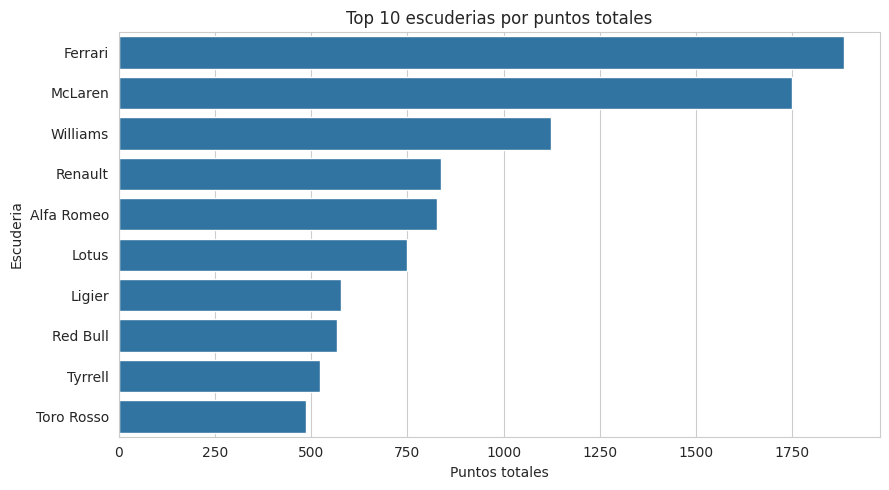

In [0]:
# 3.1 Top escuderias por puntos totales acumulados
# resultado esta a nivel piloto+carrera; usamos auto para saber con que escuderia corrio cada piloto
resultado_auto = resultado.merge(
    auto[["id_piloto", "id_escuderia"]], on="id_piloto", how="left"
)

puntos_por_escuderia = (
    resultado_auto.groupby("id_escuderia")["puntos_obtenidos"]
    .sum()
    .reset_index()
    .merge(escuderia[["id_escuderia", "nombre"]], on="id_escuderia")
    .sort_values("puntos_obtenidos", ascending=False)
)

print("=== Top 10 escuderias por puntos totales ===")
display(puntos_por_escuderia[["nombre", "puntos_obtenidos"]].head(10))

fig, ax = plt.subplots()
sns.barplot(
    data=puntos_por_escuderia.head(10),
    x="puntos_obtenidos", y="nombre", ax=ax, color="#1f77b4"
)
ax.set_title("Top 10 escuderias por puntos totales")
ax.set_xlabel("Puntos totales")
ax.set_ylabel("Escuderia")
plt.tight_layout()
plt.show()

=== Top 10 escuderias por presupuesto ===


nombre,presupuesto
Brawn,5.8880770949E8
Matra,5.7710270873E8
Vanwall,5.7049852333E8
McLaren,5.5825248603E8
Ligier,4.7617688063E8
Mercedes,4.572830873E8
Maserati,4.4536125618E8
Lotus,4.2927126445E8
BRM,4.2317152605E8
Alfa Romeo,3.6785771342E8


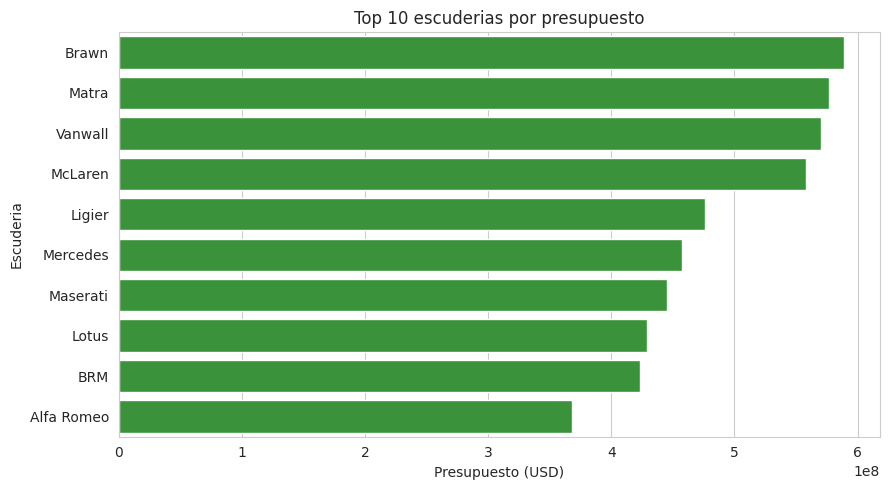

In [0]:
# 3.2 Top escuderias por presupuesto
top_presupuesto = escuderia[["nombre", "presupuesto"]].sort_values("presupuesto", ascending=False)

print("=== Top 10 escuderias por presupuesto ===")
display(top_presupuesto.head(10))

fig, ax = plt.subplots()
sns.barplot(data=top_presupuesto.head(10), x="presupuesto", y="nombre", ax=ax, color="#2ca02c")
ax.set_title("Top 10 escuderias por presupuesto")
ax.set_xlabel("Presupuesto (USD)")
ax.set_ylabel("Escuderia")
plt.tight_layout()
plt.show()

=== Top 10 escuderias por monto de patrocinio recibido ===


nombre,monto_aporte
McLaren,3.75951086E8
Brabham,3.726408763E8
Red Bull,3.2933975575E8
Mercedes,3.2865196495E8
Williams,3.1212964195E8
Benetton,2.965197231E8
Lotus,2.830637451E8
Tyrrell,2.402960754E8
Ferrari,2.356430823E8
Renault,2.3394075315E8


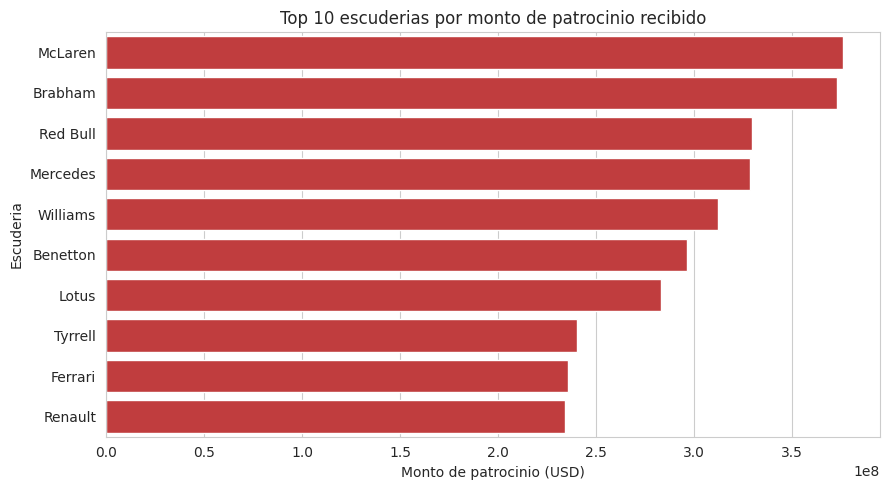

In [0]:
# 3.3 Top escuderias por monto total de patrocinio recibido
patrocinio_por_escuderia = (
    financiamiento.groupby("id_escuderia")["monto_aporte"]
    .sum()
    .reset_index()
    .merge(escuderia[["id_escuderia", "nombre"]], on="id_escuderia")
    .sort_values("monto_aporte", ascending=False)
)

print("=== Top 10 escuderias por monto de patrocinio recibido ===")
display(patrocinio_por_escuderia[["nombre", "monto_aporte"]].head(10))

fig, ax = plt.subplots()
sns.barplot(
    data=patrocinio_por_escuderia.head(10),
    x="monto_aporte", y="nombre", ax=ax, color="#d62728"
)
ax.set_title("Top 10 escuderias por monto de patrocinio recibido")
ax.set_xlabel("Monto de patrocinio (USD)")
ax.set_ylabel("Escuderia")
plt.tight_layout()
plt.show()

In [0]:
# 3.4 Top escuderias segun campeonatos acumulados de sus pilotos
campeonatos_por_escuderia = (
    piloto.groupby("id_escuderia")["cantidad_campeonatos"]
    .sum()
    .reset_index()
    .merge(escuderia[["id_escuderia", "nombre"]], on="id_escuderia")
    .sort_values("cantidad_campeonatos", ascending=False)
)

print("=== Top 10 escuderias por campeonatos acumulados de sus pilotos ===")
display(campeonatos_por_escuderia[["nombre", "cantidad_campeonatos"]].head(10))

=== Top 10 escuderias por campeonatos acumulados de sus pilotos ===


nombre,cantidad_campeonatos
Ferrari,11
McLaren,9
Red Bull,8
Mercedes,7
Cooper,3
Lotus,3
Brabham,3
Renault,2
BRM,2
Benetton,1


=== Correlacion entre presupuesto, puntos y patrocinio ===
La diagonal es 1 siempre (una variable se correlaciona perfecto consigo misma).
Eso NO es una matriz identidad: fuera de la diagonal se ve la relacion real
entre pares de variables distintas (va de -1 a 1, casi nunca exactamente 0).


presupuesto,puntos_obtenidos,monto_aporte
1.0,0.011,-0.147
0.011,1.0,0.4
-0.147,0.4,1.0


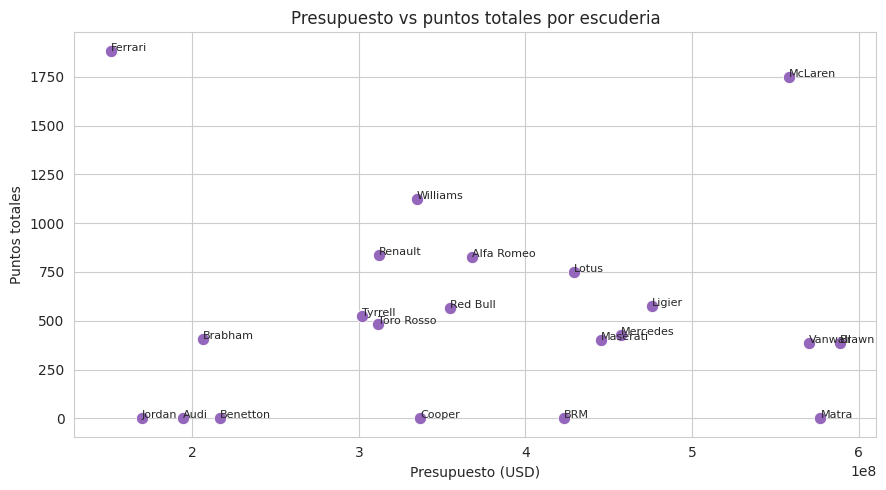

In [0]:
# 3.5 Relacion entre presupuesto y puntos totales (para ver si mas presupuesto = mejor desempeno)
resumen_escuderia = (
    escuderia[["id_escuderia", "nombre", "presupuesto"]]
    .merge(puntos_por_escuderia[["id_escuderia", "puntos_obtenidos"]], on="id_escuderia", how="left")
    .merge(patrocinio_por_escuderia[["id_escuderia", "monto_aporte"]], on="id_escuderia", how="left")
    .fillna(0)
)

correlacion = resumen_escuderia[["presupuesto", "puntos_obtenidos", "monto_aporte"]].corr().round(3)
print("=== Correlacion entre presupuesto, puntos y patrocinio ===")
print("La diagonal es 1 siempre (una variable se correlaciona perfecto consigo misma).")
print("Eso NO es una matriz identidad: fuera de la diagonal se ve la relacion real")
print("entre pares de variables distintas (va de -1 a 1, casi nunca exactamente 0).")
display(correlacion)

fig, ax = plt.subplots()
sns.scatterplot(data=resumen_escuderia, x="presupuesto", y="puntos_obtenidos", ax=ax, s=80, color="#9467bd")
for _, fila in resumen_escuderia.iterrows():
    ax.annotate(fila["nombre"], (fila["presupuesto"], fila["puntos_obtenidos"]), fontsize=8)
ax.set_title("Presupuesto vs puntos totales por escuderia")
ax.set_xlabel("Presupuesto (USD)")
ax.set_ylabel("Puntos totales")
plt.tight_layout()
plt.show()

## 4. Resumen de hallazgos

- Se calcularon los **promedios generales** del proyecto (presupuesto, peso de pilotos,
  campeonatos, condiciones de carrera y puntos).
- Se analizaron las **distribuciones** de presupuesto, puntos, posición final y nacionalidad
  de los pilotos, identificando concentraciones y valores atípicos.
- Se construyó el **ranking de escuderías** bajo cuatro criterios distintos (puntos, presupuesto,
  patrocinio recibido y campeonatos de sus pilotos), junto con la correlación entre presupuesto,
  patrocinio y desempeño en pista.

In [0]:
spark.createDataFrame(puntos_por_escuderia).write.mode("overwrite").saveAsTable("puntos_por_escuderia")
spark.createDataFrame(top_presupuesto).write.mode("overwrite").saveAsTable("top_presupuesto_escuderia")
spark.createDataFrame(patrocinio_por_escuderia).write.mode("overwrite").saveAsTable("patrocinio_por_escuderia")
spark.createDataFrame(campeonatos_por_escuderia).write.mode("overwrite").saveAsTable("campeonatos_por_escuderia")
spark.createDataFrame(resumen_escuderia).write.mode("overwrite").saveAsTable("resumen_escuderia")

print("Tablas de resumen guardadas: puntos_por_escuderia, top_presupuesto_escuderia,")
print("patrocinio_por_escuderia, campeonatos_por_escuderia, resumen_escuderia")
print("\nListo para el notebook 04_analisis_sql y 05_analitica_avanzada.")

Tablas de resumen guardadas: puntos_por_escuderia, top_presupuesto_escuderia,
patrocinio_por_escuderia, campeonatos_por_escuderia, resumen_escuderia

Listo para el notebook 04_analisis_sql y 05_analitica_avanzada.
